In [2]:
import pandas as pd
import re
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
df = pd.read_csv('module_data.csv')

In [3]:
df.head(20)

,id,name,credits,WLH,attendance_time,selfstudy_time,AR,RPK,frequency,duration,RS,examination_type,examination_prerequisites,note,study_area
0,B.Bio-NF.117,Genomanalyse - Vorlesung mit Übung,6,4.0,56.0,124.0,BSc Bio: mindestens 40 C aus dem ersten,Für die Veranstaltung werden grundlegende,jedes Sommersemester,1.0,3 - 6,Klausur,NaN,Das Modul kann nicht in Kombination mit B.Bio....,['I.2.a.II.2.a']
1,B.Bio-NF.129,Genetik und mikrobielle Zellbiologie,6,4.0,56.0,124.0,keine,Biologische Grundkenntnisse,jedes Sommersemester,1.0,4 - 6,Klausur,NaN,Das Modul kann nicht in Kombination mit B.Bio....,['I.2.a.II.2.b']
2,B.Bio-NF.130,Kognitionspsychologie,3,2.0,28.0,62.0,keine,keine,jedes Wintersemester,1.0,ab 3,Klausur,NaN,Das Modul kann nicht in Kombination mit B.Bio....,"['I.2.a.II.2.b', 'I.2.a.IX.2.b']"
3,B.Bio.102,Ringvorlesung Biologie II,8,6.0,84.0,156.0,keine,keine,jedes Sommersemester,1.0,2,Klausur,NaN,Die Klausuren werden als E-Prüfungen durchgeführt,['I.2.a.II.2.a']
4,B.ES.115,Ecological Modelling,6,4.0,56.0,124.0,none,none,each winter semester,1.0,3,Oral Presentation,Written examination (30 minutes); ungraded,NaN,['I.2.a.IV.1.a']
5,B.Forst.1101,Grundlagen der Forstbotanik,6,4.0,56.0,124.0,keine,keine,jedes Wintersemester,1.0,1,Klausur,NaN,NaN,['I.2.a.IV.2.a']
6,B.Forst.1105,Angewandte Informatik (inkl. GIS),6,4.0,56.0,124.0,keine,keine,jedes Wintersemester,1.0,1,Klausur,NaN,NaN,['I.2.a.IV.1.a']
7,B.Forst.1108,Bodenkunde,6,4.0,56.0,124.0,keine,Naturwissenschaftliche Grundlagen (B.Forst.1103),jedes Sommersemester,1.0,2,Klausur,NaN,NaN,['I.2.a.IV.2.a']
8,B.Forst.1114,Forstgenetik,6,4.0,56.0,124.0,keine,keine,jedes Wintersemester,1.0,3,Klausur,NaN,NaN,['I.2.a.IV.2.b']
9,B.Forst.1128,Morphologie & Systematik der Waldpflanzen,9,3.0,42.0,228.0,keine,keine,jedes Sommersemester,2.0,NaN,Klausur,NaN,NaN,['I.2.a.IV.2.a']


In [4]:
# id/ name column clean up. checking which column have no name/id, manually adding values
df[df['id'].isna() | df['name'].isna()]


,id,name,credits,WLH,attendance_time,selfstudy_time,AR,RPK,frequency,duration,RS,examination_type,examination_prerequisites,note,study_area
194,NaN,NaN,3,2.0,28.0,62.0,none,Knowledge of basic statistics concepts,each semester,1.0,NaN,Written examination,NaN,Dieses Modul kann nur von Studierenden des Bac...,[]


In [5]:
df.loc[194, 'id'] = 'B.iPAB.0014'
df.loc[194, 'name'] = 'Data Analysis with R'

In [6]:
df['name'] = df['name'].str.replace('\n', ' ')

In [7]:
# credits/WLH column clean up. checking which column have no credits/WLH, manually adding values
df[df['credits'].isna() | df['WLH'].isna()]
# WLH are calculated from credits as weekly workload
df['WLH'] = (df['credits']*30)/14


In [8]:
df[df['attendance_time'].isna() | df['selfstudy_time'].isna()]
# pdfplumber didnt extrat the table as it didnt close on this page. manually adding values
df.loc[82, ['attendance_time', 'selfstudy_time']] = [84, 186]
df.loc[83, ['attendance_time', 'selfstudy_time']] = [84, 186]
df.loc[86, ['attendance_time', 'selfstudy_time']] = [56, 124]
df.loc[90, ['attendance_time', 'selfstudy_time']] = [28, 224]
df.loc[117, ['attendance_time', 'selfstudy_time']] = [84, 186]
df.loc[119, ['attendance_time', 'selfstudy_time']] = [84, 186]
df.loc[125, ['attendance_time', 'selfstudy_time']] = [84, 186]
df.loc[127, ['attendance_time', 'selfstudy_time']] = [84, 186]
df.loc[128, ['attendance_time', 'selfstudy_time']] = [84, 186]
df.loc[134, ['attendance_time', 'selfstudy_time']] = [28, 62]
df.loc[227, ['attendance_time', 'selfstudy_time']] = [0, 0]

In [9]:
df[df['AR'].isna() | df['RPK'].isna()]
df['AR'] = df['AR'].astype(object)
df['RPK'] = df['RPK'].astype(object)
df.loc[13, ['AR', 'RPK']] = ['none', 'none']
df.loc[48, ['AR', 'RPK']] = ['none', 'none']
df.at[62, 'AR'] = 'none'
df.at[62, 'RPK'] = ['B.Inf.1101', 'B.Inf.1210']
df.at[88, 'AR'] = 'none'
df.at[88, 'RPK'] = ['B.Mat.0732', 'B.Mat.1013']
df.at[101, 'AR'] = 'none'
df.at[101, 'RPK'] = ['B.Mat.1011']
df.at[104, 'AR'] = 'none'
df.at[104, 'RPK'] = ['B.Mat.1014']
df.loc[187, ['AR', 'RPK']] = ['none', 'none']

In [10]:
df.loc[df['AR'] == 'keine', 'AR'] = 'none' 
df.loc[df['RPK'] == 'keine', 'RPK'] = 'none' 

In [11]:
df[df['RPK'].isna()]

,id,name,credits,WLH,attendance_time,selfstudy_time,AR,RPK,frequency,duration,RS,examination_type,examination_prerequisites,note,study_area


In [12]:
# Admission Requierments coloumn to list
def extract_modules(value):
    """
    Extract module IDs from text.
    Handles: B.Inf.1101, B.Mat.0732, or multiple separated by commas/newlines.
    """

    if isinstance(value, list):
        return value
    

    if value is None or value == 'none':
        return []
    

    if isinstance(value, str):

        modules = re.findall(r'B\.[A-Za-z]+\.\d+', value)

        seen = set()
        result = []
        for m in modules:
            if m not in seen:
                seen.add(m)
                result.append(m)
        return result
    
    return []

def extract_modules_with_logic(value):
    """
    Extract module IDs with logic operators.
    
    Returns dict with:
    - 'all': modules that ALL must be completed
    - 'any': modules where ANY ONE must be completed
    
    Examples:
    "B.Inf.1101" -> {'all': ['B.Inf.1101'], 'any': []}
    "B.Inf.1801 oder B.Inf.1841" -> {'all': [], 'any': ['B.Inf.1801', 'B.Inf.1841']}
    "B.Inf.1101, B.Inf.1102" -> {'all': ['B.Inf.1101', 'B.Inf.1102'], 'any': []}
    """
    if isinstance(value, dict):
        return value
    
    if value is None or value == 'none':
        return {'all': [], 'any': []}
    
    if isinstance(value, str):
        # Suche nach Modul-IDs
        modules = re.findall(r'B\.[A-Za-z]+\.\d+', value)
        
        if not modules:
            return {'all': [], 'any': []}
        
        # Prüfe ob "oder" / "or" im Text vorkommt (= any)
        if 'oder' in value.lower() or ' or ' in value.lower():
            return {'all': [], 'any': modules}
        
        # Sonst: alle müssen erfüllt sein (AND)
        return {'all': modules, 'any': []}
    
    return {'all': [], 'any': []}


# Anwenden
df['AR'] = df['AR'].apply(extract_modules_with_logic)
df['RPK'] = df['RPK'].apply(extract_modules)

In [13]:
df[df['frequency'].isna() | df['duration'].isna()]

df.loc[11, ['frequency', 'duration']] = ['jährlich', '2']
df.loc[15, ['frequency', 'duration']] = ['jedes Wintersemester', '1']
df.loc[23, ['frequency', 'duration']] = ['jedes Wintersemester', '1']
df.loc[27, ['frequency', 'duration']] = ['jährlich', '1']
df.loc[36, ['frequency', 'duration']] = ['jedes Sommersemester', '1']
df.loc[102, ['frequency', 'duration']] = ['jedes Sommersemester', '1']
df.loc[108, ['frequency', 'duration']] = ['each winter semester', '1']
df.loc[110, ['frequency', 'duration']] = ['each winter semester', '1']
df.loc[189, ['frequency', 'duration']] = ['jedes Sommersemester', '1']
df.loc[227, ['frequency', 'duration']] = ['jedes Semester', '0']

C:\Users\emily\AppData\Local\Temp\ipykernel_11292\248286143.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[11, ['frequency', 'duration']] = ['jährlich', '2']


In [14]:
df['frequency'].unique()

array(['jedes Sommersemester', 'jedes Wintersemester',
       'each winter semester', 'jährlich', 'jedes Semester',
       'once a year', 'each summer semester', 'irregular', 'unregelmäßig',
       'each semester', 'keine Angabe', 'every 4th semester',
       'not specified', 'Usually subsequent to the module B.Mat.3131',
       'Usually subsequent to the module B.Mat.3132',
       'Usually subsequent to the module B.Mat.3133',
       'Usually subsequent to the module B.Mat.3134',
       'Usually subsequent to the module B.Mat.3137',
       'Usually subsequent to the module B.Mat.3138',
       'Usually subsequent to the module B.Mat.3139', 'jedes 4. Semester',
       'jedes Semester; im SoSe als Aufzeichnung'], dtype=object)

In [15]:
# S: every Sommersemester, W, every winter semester, E: every semester, N: not specified
df['frequency'] = df['frequency'].replace({
    'jedes Sommersemester': 'S', 
    'jedes Wintersemester': 'W',
    'each winter semester': 'W',
    'jährlich': 'N',
    'jedes Semester': 'E',
    'once a year': 'N',
    'each summer semester': 'S',
    'unregelmäßig': 'N',
    'each semester': 'E',
    'keine Angabe': 'N',
    'every 4th semester': 'N',
    'not specified': 'N',
    'Usually subsequent to the module B.Mat.3131': 'N',
    'Usually subsequent to the module B.Mat.3132': 'N',
    'Usually subsequent to the module B.Mat.3133': 'N',
    'Usually subsequent to the module B.Mat.3134': 'N',
    'Usually subsequent to the module B.Mat.3137': 'N',
    'Usually subsequent to the module B.Mat.3138': 'N',
    'Usually subsequent to the module B.Mat.3138': 'N',
    'Usually subsequent to the module B.Mat.3139': 'N',
    'irregular': 'N',
    'unregelmäßig': 'N',
    'jedes 4. Semester': 'N',
    'jedes Semester; im SoSe als Aufzeichnung': 'E',
    'I': 'N'
})

In [16]:
df['examination_type'] = df['examination_type'].fillna('Exam')
mapping = {
    'Klausur': 'Written', 'Mündlich': 'Oral', 'Präsentation': 'Presentation',
    'Vortrag': 'Presentation', 'Praktikumsbericht': 'Report', 'Hausarbeit': 'Paper',
    'Klausur bzw. E-Prüfung': 'Written', 'Take-Home-Klausur': 'Take-Home',
    'Vortrag Seminarvortrag': 'Presentation', 'Gruppenreferat': 'Presentation',
    'Seminararbeit': 'Paper', 'Bachelorarbeit': 'Bachelor Thesis',
    'Projektarbeitsbericht': 'Report', 'GIS-Projektarbeit inkl. schriftlicher Ausarbeitung': 'Report',
    'Wissenschaftlicher Bericht/Protokoll': 'Report', 'Schriftlicher Bericht': 'Report',
    'Projektarbeit': 'Project', 'Bearbeitung von Übungszetteln': 'Exercise Sheets',
    'Praktische Modulprüfung': 'Practical Module Exam', 'Exam': 'Exam',
    'Written examination': 'Written', 'written examination': 'Written', 'Written': 'Written',
    'Oral examination': 'Oral', 'Oral Presentation': 'Presentation', 'Portfolio': 'Portfolio',
    'Project work': 'Project', 'Practical project': 'Project',
    'Portfolio as a versioned programming project': 'Portfolio', 'Presentation': 'Presentation',
    'Talk': 'Presentation', 'Lecture': 'Lecture', 'Written report': 'Report',
    'oral': 'Oral', 'Written or oral examwritten examination': 'Written or Oral',
    'Written or oral examWritten exam': 'Written or Oral',
    'Assignment and short presentation of results': 'Presentation',
    'Written Exam': 'Written'
}
df['examination_type'] = df['examination_type'].map(mapping).fillna(df['examination_type']).str.title()
df.loc[80, 'examination_type']='Project'
df.loc[164, 'examination_type']='Project'
df.loc[184, 'examination_type']='Paper'
df.loc[227, 'examination_type']='Project'
df.loc[229, 'examination_type']='Project'
df.loc[df['examination_type'] == 'Written Exam', 'examination_type'] = 'Written'

In [17]:
# note_en + study_restriction
df['note'] = df['note'].fillna('None')
translation_map = {
    'Das Modul kann nicht in Kombination mit B.Bio.117 oder SK.Bio.117 belegt werden.': 'Cannot be combined with B.Bio.117 or SK.Bio.117',
    'Das Modul kann nicht in Kombination mit B.Bio.129 belegt werden.': 'Cannot be combined with B.Bio.129',
    'Das Modul kann nicht in Kombination mit B.Bio.130 belegt werden.': 'Cannot be combined with B.Bio.130',
    'Ausschluss: Dieses Modul darf nicht belegt werden, wenn B.Phy.5667 oder B.Phy.5668 schon belegt': 'Exclusion: Cannot take if B.Phy.5667/5668 already completed',
    'Sobald das Modul M.Forst.221 erfolgreich absolviert wurde, kann das Modul M.Forst.739 nicht mehr belegt': 'M.Forst.739 excluded after completing M.Forst.221',
    'Dozent\\*in: Lehrpersonen des Mathematischen Instituts': 'Lecturers: Mathematical Institute',
    'Dozent\\*in: Lehrpersonen des Instituts für Numerische und Angewandte Mathematik': 'Lecturers: Institute for Numerical Math',
    'Dozent\\*in: Lehrpersonen des Instituts für Mathematische Stochastik': 'Lecturers: Institute for Mathematical Stochastics',
    'Instructor: Lecturers at the Institute of Numerical and Applied Mathematics': 'Lecturers: Numerical Math Institute',
    'Instructor: Lecturers at the Mathematical Institute': 'Lecturers: Mathematical Institute',
    '• Dozent\\*in: Lehrpersonen des Mathematischen Instituts': 'Lecturers: Mathematical Institute',
    'Die Klausuren werden als E-Prüfungen durchgeführt': 'Exams as electronic tests',
    'Durch erfolgreiches Lösen und Erklären der Übungsaufgaben können Bonus-Prozent für die Klausur': 'Bonus points for solved exercises',
    'Die Prüfungsleistung kann neben Deutsch auch auf Englisch erbracht werden.': 'Exam possible in English',
    'Angebotshäufigkeit': 'Offered irregularly'
}
df['note'] = df['note'].replace(translation_map, regex=True).str.strip().str.title()
df['study_restriction'] = df['note'].str.contains('cannot|exclusion|excluded|combined', case=False, na=False).map({True: 'relevant', False: []})



In [18]:
df[df['study_restriction'] == 'relevant']

,id,name,credits,WLH,attendance_time,selfstudy_time,AR,RPK,frequency,duration,RS,examination_type,examination_prerequisites,note,study_area,study_restriction
0,B.Bio-NF.117,Genomanalyse - Vorlesung mit Übung,6,12.857143,56.0,124.0,"{'all': [], 'any': []}",[],S,1.0,3 - 6,Written,NaN,Cannot Be Combined With B.Bio.117 Or Sk.Bio.117,['I.2.a.II.2.a'],relevant
1,B.Bio-NF.129,Genetik und mikrobielle Zellbiologie,6,12.857143,56.0,124.0,"{'all': [], 'any': []}",[],S,1.0,4 - 6,Written,NaN,Cannot Be Combined With B.Bio.129,['I.2.a.II.2.b'],relevant
2,B.Bio-NF.130,Kognitionspsychologie,3,6.428571,28.0,62.0,"{'all': [], 'any': []}",[],W,1.0,ab 3,Written,NaN,Cannot Be Combined With B.Bio.130,"['I.2.a.II.2.b', 'I.2.a.IX.2.b']",relevant
165,B.Phy.5676,Computer Vision and Robotics,9,19.285714,84.0,186.0,"{'all': [], 'any': []}",[],W,1.0,NaN,Report,NaN,Exclusion: Cannot Take If B.Phy.5667/5668 Alre...,['I.2.a.IX.1.b'],relevant
196,M.Forst.221,Fernerkundung und GIS,6,12.857143,56.0,124.0,"{'all': [], 'any': []}",[],S,1.0,NaN,Written,NaN,M.Forst.739 Excluded After Completing M.Forst.221,['I.2.a.IV.1.a'],relevant
222,SK.Bio.356,Biologische Psychologie II,3,6.428571,28.0,62.0,"{'all': [], 'any': []}",[],W,1.0,3 - 5,Written,NaN,Cannot Be Combined With B.Bio.130,"['I.2.a.II.2.b', 'I.2.a.IX.2.a']",relevant


In [19]:
df.at[0, 'study_restriction'] = ['B.Bio.117', 'SK.Bio.117']
df.at[1, 'study_restriction'] = ['B.Bio.129']
df.at[2, 'study_restriction'] = ['B.Bio.130']
df.at[165, 'study_restriction'] = ['B.Phy.5667', 'B.Phy.5668']
df.at[222, 'study_restriction'] = ['B.Bio.130']

In [20]:
df.drop('note', axis=1, inplace=True)

In [21]:
def string_to_list(s):
    if pd.isna(s) or s is None:
        return []
    match = re.search(r'Bachelor:\s*(\d+)\s*(?:-\s*(\d+))?\s*', s)
    if match:
        start = int(match.group(1))
        end = int(match.group(2)) if match.group(2) else start
        return list(range(start, end + 1))
    match = re.search(r'(\d+)\s*-\s*(\d+)', s)
    if match:
        return list(range(int(match.group(1)), int(match.group(2))+1))
    match = re.search(r'(ab|from)\s*(\d+)', s)
    if match:
        return list(range(int(match.group(2)), 7))
    if s.strip().isdigit():
        return([int(s)])
    return([])


In [22]:
df['RS'] = df['RS'].apply(string_to_list)
df['RS']

0      [3, 4, 5, 6]
1         [4, 5, 6]
2      [3, 4, 5, 6]
3               [2]
4               [3]
           ...     
226              []
227              []
228       [3, 4, 5]
229              []
230          [5, 6]
Name: RS, Length: 231, dtype: object

In [23]:
df.at[9, 'RS'] = [1, 2]
df.at[52, 'RS'] = [2, 3, 4, 5, 6]
df.at[87, 'RS'] = [1, 2, 3, 4, 5, 6]
df.at[111, 'RS'] = [4, 5, 6]
df.at[165, 'RS'] = [5, 6]
df.at[171, 'RS'] = [3, 4]
df.at[180, 'RS'] = [2]

In [24]:
df['examination_prerequisites'].unique()

array([nan, 'Written examination (30 minutes); ungraded',
       'Regelmäßige Teilnahme am Übungsteil',
       'Regelmäßige Teilnahme an der Übung',
       'Regelmäßige Teilnahme an der Übung; 3 Übungsaufgaben à max. 3 Seiten',
       'Regelmäßige Teilnahme an der Übung; 2 Geländeprotokolle zu den Exkursionstagen à',
       'Regelmäßige Teilnahme an der Übung; Referat (ca.30 Min.) mit schriftlicher',
       'Die theoretischen und die praktischen Übungen aller Übungsblätter müssen jeweils',
       'Alle Übungsblätter müssen jeweils mit mindestens 40% der erreichbaren Punkte',
       'Mindestens 50% der Übungspunkte',
       'Bearbeitung von 50% aller Übungsblätter, Vorführung mindestens einer Aufgabe',
       'Aktive Teilnahme an den Übungen, belegt durch Nachweis von 50% der in den',
       'Erarbeiten und Vorstellen der Lösung mindestens einer Übungsaufgabe (Präsentation',
       'Teilnahme am Proseminar.',
       'B.Inf.1209.Ue: Erarbeiten und Vorstellen der Lösung mindestens einer Ü

In [25]:
df[df['examination_prerequisites'] ==  'Mündlich (ca. 15 Min.) oder Klausur (90 Min.) oder Hausarbeit (mind. 10 Seiten) oder']

,id,name,credits,WLH,attendance_time,selfstudy_time,AR,RPK,frequency,duration,RS,examination_type,examination_prerequisites,study_area,study_restriction
209,S.RW.1168,Introduction to European ICT and Media Law,6,12.857143,28.0,152.0,"{'all': [], 'any': []}",[],S,1.0,[],Oral,Mündlich (ca. 15 Min.) oder Klausur (90 Min.) ...,['I.2.a.VI.1.a'],[]


In [26]:
def ex_req(s):
    if pd.isna(s):
        return 'none'
    s = str(s).strip()
    # Modul-Prefix entfernen (z.B. "B.Inf.1209.Ue: ")
    s = re.sub(r'^[A-Za-z]\.[A-Za-z]+\.\d+\w*[.;]\w+[;:]?\s*', '', s)
    sl = s.lower()

    # None
    if re.search(r'^(keine|none|nan)$', sl):
        return 'none'
    if re.search(r'details zum organisatorischen ablauf von externen praktika', sl):
        return 'none'
    if re.search(r'siehe erweitertes modul', sl):
        return 'none'
    if re.search(r'mündlich.*oder.*klausur.*oder.*hausarbeit', sl):
        return 'none'

    # Written Exam
    if re.search(r'written examination.*ungraded', sl):
        return 'written exam'

    # 50% + present n-1 times
    if re.search(r'50%.*n-?1 attempts presented', sl):
        return '50% of exercises and present n-1 times'

    # 50% + present twice (zweimaliges)
    if re.search(r'50%.*zweimaliges', sl):
        return '50% of exercise and present twice'

    # 50% + presentation (achievement ... and presentation)
    if re.search(r'(achievement of at least 50%|erreichen von mindestens 50%).*presentation', sl):
        return '50% of exercise and present twice'

    # 50% + engagierte (as well as committed)
    if re.search(r'(50%.*engagierte|as well as committed)', sl):
        return '50% of exercise'

    # 50% + Anwesenheit
    if re.search(r'50%.*anwesenheit|anwesenheit.*50%', sl):
        return '50% of exercise and attandance'

    # 40% on all Exercise Sheets
    if re.search(r'(theoretischen und.*praktischen übungen aller übungsblätter|mindestens 40%.*übungsblätter|40%.*erreichbaren punkte)', sl):
        return '40% on every excercise sheets'

    # 65% Programmieraufgaben
    if re.search(r'65%.*programmieraufgaben', sl):
        return '65% of excercise'

    # 50% of exercises (alle Varianten)
    if re.search(r'(mindestens 50%|mind\. 50%|mindestens 50 %|at least 50%|>=50%|50% of the homework|50% aller übungsblätter|50%.*übungspunkte|50%.*hausaufgaben|50%.*homework|50%.*übungsblätter|50%.*übungsaufgaben)', sl):
        return '50% of exercise'

    # Presentation of one exercise
    if re.search(r'(vorführung mindestens einer aufgabe|erarbeiten und vorstellen.*lösung|vorstellen der lösung.*übungsaufgabe|develop and present.*solution.*at least one exercise)', sl):
        return 'presentation of one exercise'

    # Completion Of Exercise
    if re.search(r'(successful completion of exercise projects|erfolgreiche bearbeitung von (praktischen aufgaben|übungsaufgaben))', sl):
        return 'completion of exercise'

    # <5 solved exercises
    if re.search(r'(4 erfolgreich bearbeitete|drei erfolgreich testierte|drei von drei erfolgreich)', sl):
        return '<5 solved exercises'

    # Oral Presentation
    if re.search(r'oral presentation', sl):
        return 'presentation'

    # Mündlicher Vortrag / Referat + Teilnahme
    if re.search(r'(referat.*mit schriftlicher|mündlicher vortrag|präsentation mindestens einer übungslösung)', sl):
        return 'active participation and presentation'

    # Attendance and <5 Exercises
    if re.search(r'(regelmäßige teilnahme.*übung.*\d|teilnahme.*übung.*absolvieren|regelmäßige.*kursteilnahme.*abgabe|regelmäßige teilnahme.*arbeitsauftr)', sl):
        return 'attandance and <5 exercises'

    # Active Participation and Presentation (Teilnahme + Präsentation)
    if re.search(r'teilnahme.*übungsbetrieb.*präsentation', sl):
        return 'active participation and presentation'

    # Attendance (nur Teilnahme ohne weiteres)
    if re.search(r'(regelmäßige (teilnahme|anwesenheit)|kontinuierliche teilnahme|regular participation|attendance to seminar|participation in the seminar|teilnahme am (pro)?seminar)', sl):
        return 'attendance'

    # Active Participation
    if re.search(r'(aktive teilnahme|active participation|aktive mitwirkung|teilnahme am planspiel)', sl):
        return 'active participation'

    return s


In [27]:
df['examination_prerequisites'] = df['examination_prerequisites'].apply(ex_req)
df['examination_prerequisites'].fillna('None')

0                      none
1                      none
2                      none
3                      none
4              written exam
               ...         
226              attendance
227    active participation
228                    none
229                    none
230              attendance
Name: examination_prerequisites, Length: 231, dtype: object

In [29]:
def parse_grades(filepath):
    results = []
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = [l.strip() for l in f if l.strip() and not l.startswith('#')]
    
    i = 0
    while i < len(lines):
        module_id = lines[i]; i += 1
        entries = []
        
        while i + 2 <= len(lines):
            try:
                bestanden = int(lines[i])
                durchgefallen = int(lines[i+1])
                avg = float(lines[i+2])
                total = bestanden + durchgefallen
                entries.append({
                    'avg_grade': avg,
                    'failure_rates': durchgefallen / total if total > 0 else None
                })
                i += 3
            except ValueError:
                break
        
        if entries:
            results.append({
                'id': module_id,
                'avg_grade': sum(e['avg_grade'] for e in entries) / len(entries),
                'failure_rates': sum(e['failure_rates'] for e in entries) / len(entries)
            })
    
    return pd.DataFrame(results)

grades = parse_grades('raw_data\grades.txt')

# Join über ID statt Name
df = df.merge(grades, on='id', how='left')

<>:34: SyntaxWarning: invalid escape sequence '\g'
<>:34: SyntaxWarning: invalid escape sequence '\g'
C:\Users\emily\AppData\Local\Temp\ipykernel_11292\4050860579.py:34: SyntaxWarning: invalid escape sequence '\g'
  grades = parse_grades('raw_data\grades.txt')


In [30]:
def count_all_dependencies(module_id, df, memo=None):
    if memo is None:
        memo = {}
    if module_id in memo:
        return memo[module_id]

    row = df[df['id'] == module_id]
    if row.empty:
        memo[module_id] = 0
        return 0

    rpk_deps = row.iloc[0]['RPK']  # einzelne Liste


    total = len(rpk_deps) 

    for dep in rpk_deps:
        total += count_all_dependencies(dep, df, memo)

    memo[module_id] = total
    return total

In [31]:
# k means analysis of modules 
# classification into leicht mittel hart
# anpassen/skalieren der kategorien
exam_prereq_order = {
    'none': 0,
    'attendance': 1,
    'active participation': 2,          # nur minimal mehr als Anwesenheit
    'attandance and <5 exercises': 2, 
    'presentation': 3,
    'presentation of one exercise': 3,
    '<5 solved exercises': 3,           # nach unten, da weniger als Completion
    'completion of exercise': 4,
    'active participation and presentation': 4,
    '50% of exercise': 5,
    '65% of excercise': 6,
    '50% of exercise and present twice': 7,
    '40% on every excercise sheets': 8,
    '50% of exercises and present n-1 times': 9,
    'written exam': 10
}
df['exam_prereq_encoded'] = df['examination_prerequisites'].map(exam_prereq_order)
memo = {}
df['rpk_count_recursive'] = df['id'].apply(
    lambda mid: count_all_dependencies(mid, df, memo)
)

features = [
    'credits',              # Gesamtworkload
    'rpk_count_recursive',  # Tiefe des Vorwissensbaums
    'exam_prereq_encoded',
    'avg_grade',
    'failure_rates'
]


In [32]:
X = df[features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

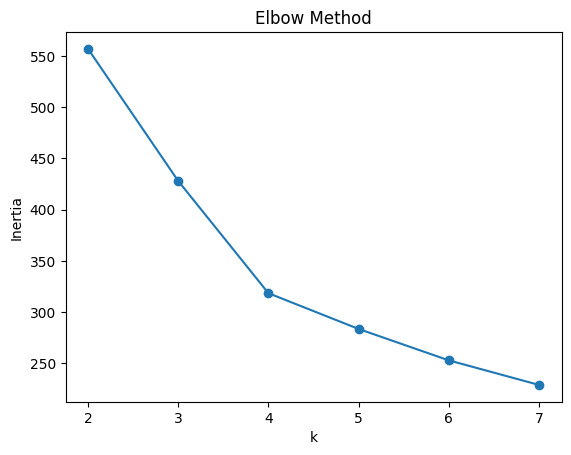

In [33]:

inertias = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(range(2, 8), inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [34]:

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)  # ← X_scaled nicht X!
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}: {score:.3f}")

k=2: 0.267
k=3: 0.278
k=4: 0.326
k=5: 0.286
k=6: 0.301
k=7: 0.268


Elbow is at k=4 and Silhouette Score is best at k=4. However k=3 is better for difficulty categories. We will test both k values to se which one is better,

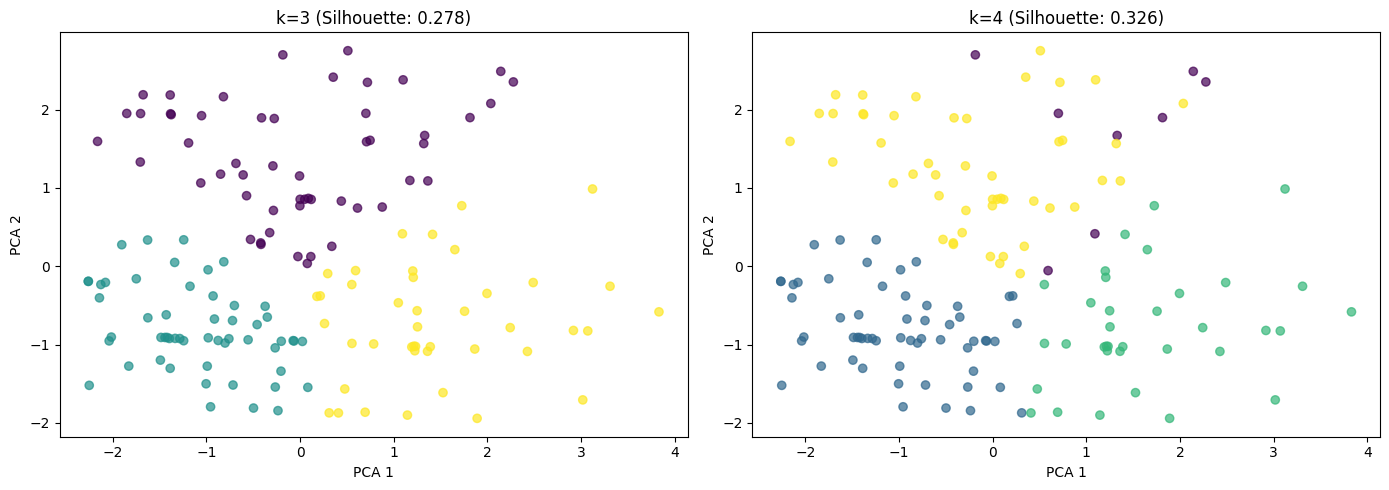

In [35]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, k in enumerate([3, 4]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    
    axes[idx].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.7)
    axes[idx].set_title(f'k={k} (Silhouette: {silhouette_score(X_scaled, labels):.3f})')
    axes[idx].set_xlabel('PCA 1')
    axes[idx].set_ylabel('PCA 2')

plt.tight_layout()
plt.show()

Eventhough k=4 has better Silhouette Score, k=3 has better Clustering. which is why we use k=3 for clustering.

In [36]:
km = KMeans(n_clusters=3, random_state=14, n_init=10)
df.loc[X.index, 'difficulty_cluster'] = km.fit_predict(X_scaled)
cluster_means = df.groupby('difficulty_cluster')[features].mean()
print(cluster_means)

                     credits  rpk_count_recursive  exam_prereq_encoded  \
difficulty_cluster                                                       
0.0                 5.952381             0.380952             0.952381   
1.0                 5.277778             0.203704             1.148148   
2.0                 8.264151             1.415094             5.452830   

                    avg_grade  failure_rates  
difficulty_cluster                            
0.0                  3.541369       0.308798  
1.0                  1.946222       0.055554  
2.0                  2.649396       0.137826  


Difficulty is modeled as a multidimensional concept that takes both exam performance metrics, average grade and failure rate, as well as structural planning complexity, credits, recommended previous knowledge (RPK) and exam prerequisites, into account.

Hard modules are characterized by high failure rates and poor average grades, despite having low exam prerequisites and low RPK counts. This can be explained by a "cold water" effect: students enter these modules with little prior knowledge of the subject matter, making concepts harder to grasp. Furthermore, the lack of mandatory preparatory work such as graded exercises means students are less structured in their preparation, resulting in poorer exam performance.

Easy modules, by contrast, show low failure rates and strong average grades. They tend to have similar exam prerequisites and higher RPK counts, meaning students have also little to no prior knowledge however as these modules are easier they have better grades.

Medium modules fall between the two extremes in terms of exam performance. Their RPK count is higher than that of the other modules. This may suggest a non-linear relationship between structural complexity and difficulty: RPK increases as modules become more advanced, peaks at a certain level, and then decreases again as highly specialized modules narrow their prerequisite scope. This happens as well with the exam prerequisites. On the one hand, students are better prepared for the exams, on the other hand, this increases their workload making the module harder.

In [37]:
label_map = {1: 'easy', 0: 'hard', 2: 'medium'}
df['difficulty'] = df['difficulty_cluster'].map(label_map)

In [38]:
# Module ohne difficulty (wurden gedroppt beim Clustering)
missing = df[df['difficulty'].isna()][features]

# NaN auffüllen (gleiche Strategie wie vorher)
missing = missing.fillna({
    'avg_grade': df['avg_grade'].median(),
    'failure_rates': df['failure_rates'].median(),
})

# Mit demselben Scaler transformieren
missing_scaled = scaler.transform(missing)  # fit_transform NICHT nochmal!

# Mit demselben km Modell predicten
df.loc[missing.index, 'difficulty_cluster'] = km.predict(missing_scaled)
df.loc[missing.index, 'difficulty'] = df.loc[missing.index, 'difficulty_cluster'].map(label_map)

In [39]:
columns_to_drop = ['exam_prereq_encoded', 'rpk_count_recursive', 'difficulty_cluster']
df.drop(columns_to_drop, axis = 1, inplace=True)

In [40]:
df.to_csv('module_data_final.csv', index=False)